In [1]:
import os, sys, gc, time

IS_KAGGLE = os.path.exists('/kaggle/input')

if IS_KAGGLE:
    DATA_DIR   = '/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1'
    IMAGE_DIR  = os.path.join(DATA_DIR, 'images')
    TRAIN_CSV  = os.path.join(DATA_DIR, 'train.csv')
    TEST_CSV   = os.path.join(DATA_DIR, 'test.csv')
    SAMPLE_CSV = os.path.join(DATA_DIR, 'sample_submission.csv')
    OUTPUT_DIR = '/kaggle/working'
else:
    DATA_DIR   = '/Users/sanskar/dev/NPPE1'
    IMAGE_DIR  = os.path.join(DATA_DIR, 'images')
    TRAIN_CSV  = os.path.join(DATA_DIR, 'train.csv')
    TEST_CSV   = os.path.join(DATA_DIR, 'test.csv')
    SAMPLE_CSV = os.path.join(DATA_DIR, 'sample_submission.csv')
    OUTPUT_DIR = DATA_DIR

print(f'Environment: {"Kaggle" if IS_KAGGLE else "Local"}')
print(f'Data dir:    {DATA_DIR}')

Environment: Kaggle
Data dir:    /kaggle/input/competitions/26-t-1-dl-gen-ainppe-1


In [2]:
# ============================================================
# CELL 2: IMPORTS
# ============================================================
if IS_KAGGLE:
    os.system('pip install timm -q')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import random
import warnings
warnings.filterwarnings('ignore')
from PIL import Image as PILImage

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    from torch.amp import autocast, GradScaler
except ImportError:
    from torch.cuda.amp import autocast, GradScaler

import torchvision.transforms as T
import timm
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = False   # faster
    torch.backends.cudnn.benchmark     = True    # auto-tune convolutions

print(f'PyTorch {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print('All imports done.')


PyTorch 2.10.0+cu128
GPU: Tesla T4
All imports done.


In [3]:
# ============================================================
# CELL 3: HYPERPARAMETERS & CONFIG
# ============================================================
CFG = {
    # Data
    'img_size'       : 384,
    'train_img_size' : 320,           # Resize for training (speed vs detail tradeoff)
    'val_img_size'   : 384,           # Full resolution for val/inference
    'num_classes'    : 20,
    'seed'           : 42,

    # Model — EfficientNet-B4 with Noisy Student pretraining
    'backbone'       : 'tf_efficientnet_b4_ns',
    'pretrained'     : True,
    'dropout'        : 0.3,

    # Training
    'epochs'         : 25,            # 25 epochs ≈ 4.2 hrs on T4
    'batch_size'     : 32,
    'val_batch_size' : 64,
    'num_workers'    : 4,
    'lr'             : 3e-4,          # Head learning rate
    'backbone_lr'    : 3e-5,          # Backbone learning rate (10x lower)
    'weight_decay'   : 1e-4,
    'label_smoothing': 0.1,
    'grad_clip'      : 1.0,

    # Strategy: NO class weights in loss function
    # Rationale: class weights destroyed calibration in prior run (val acc 11%).
    # Instead, we train a well-calibrated model and use the Bayes-optimal
    # decision rule at inference to handle the asymmetric scoring.
    'use_class_weights': False,

    # Augmentation
    'mixup_alpha'    : 0.0,           # Disabled — harmful with 6816x imbalance

    # TTA
    'use_tta'        : True,
    'tta_n'          : 4,

    # Validation
    'val_fold'       : 0,
    'n_folds'        : 5,
}

# Class names — MUST match CSV column order exactly
CLASSES = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax',
    'Pneumoperitoneum', 'Pneumomediastinum', 'Subcutaneous Emphysema',
    'Tortuous Aorta', 'Calcification of the Aorta', 'No Finding'
]

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'Config: {CFG["epochs"]} epochs, batch={CFG["batch_size"]}, lr={CFG["lr"]}')


Device: cuda
Config: 25 epochs, batch=32, lr=0.0003


In [4]:
# ============================================================
# CELL 4: LOAD & VERIFY DATA
# ============================================================
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)
sample_df = pd.read_csv(SAMPLE_CSV)

print(f'Train : {train_df.shape}  ({len(train_df):,} images)')
print(f'Test  : {test_df.shape}  ({len(test_df):,} images)')
print(f'Sample: {sample_df.shape}  (only {len(sample_df)} rows — DO NOT use for submission!)')

# Verify column names match CLASSES
csv_classes = [c for c in train_df.columns if c != 'id']
assert csv_classes == CLASSES, f'Column mismatch!\nCSV: {csv_classes}\nCLASSES: {CLASSES}'
print('\n✓ CSV columns match CLASSES list exactly')

# Verify single-label (each row has exactly one class = 1)
row_sums = train_df[CLASSES].sum(axis=1)
assert (row_sums == 1).all(), f'NOT single-label! Found {(row_sums != 1).sum()} bad rows'
print(f'✓ All {len(train_df):,} rows are single-label (sum == 1)')

# Class distribution
class_counts = train_df[CLASSES].sum().sort_values(ascending=False)
class_counts_arr = np.array([class_counts[cls] for cls in CLASSES])
class_to_idx = {cls: i for i, cls in enumerate(CLASSES)}

print(f'\nClass Distribution:')
print(f'{"Class":<35} {"Count":>8}  {"Pct":>8}')
print('-' * 55)
for cls in class_counts.index:
    n = int(class_counts[cls])
    pct = n / len(train_df) * 100
    print(f'{cls:<35} {n:>8}  {pct:>7.2f}%')
print(f'\nImbalance ratio: {class_counts.max():.0f} / {class_counts.min():.0f} = {class_counts.max()/class_counts.min():.0f}x')


Train : (51043, 21)  (51,043 images)
Test  : (17015, 1)  (17,015 images)
Sample: (10, 21)  (only 10 rows — DO NOT use for submission!)

✓ CSV columns match CLASSES list exactly
✓ All 51,043 rows are single-label (sum == 1)

Class Distribution:
Class                                  Count       Pct
-------------------------------------------------------
No Finding                             34079    66.77%
Infiltration                            5206    10.20%
Atelectasis                             2351     4.61%
Effusion                                2156     4.22%
Nodule                                  1527     2.99%
Mass                                    1249     2.45%
Pneumothorax                            1114     2.18%
Consolidation                            651     1.28%
Pleural_Thickening                       608     1.19%
Cardiomegaly                             600     1.18%
Fibrosis                                 389     0.76%
Edema                                   

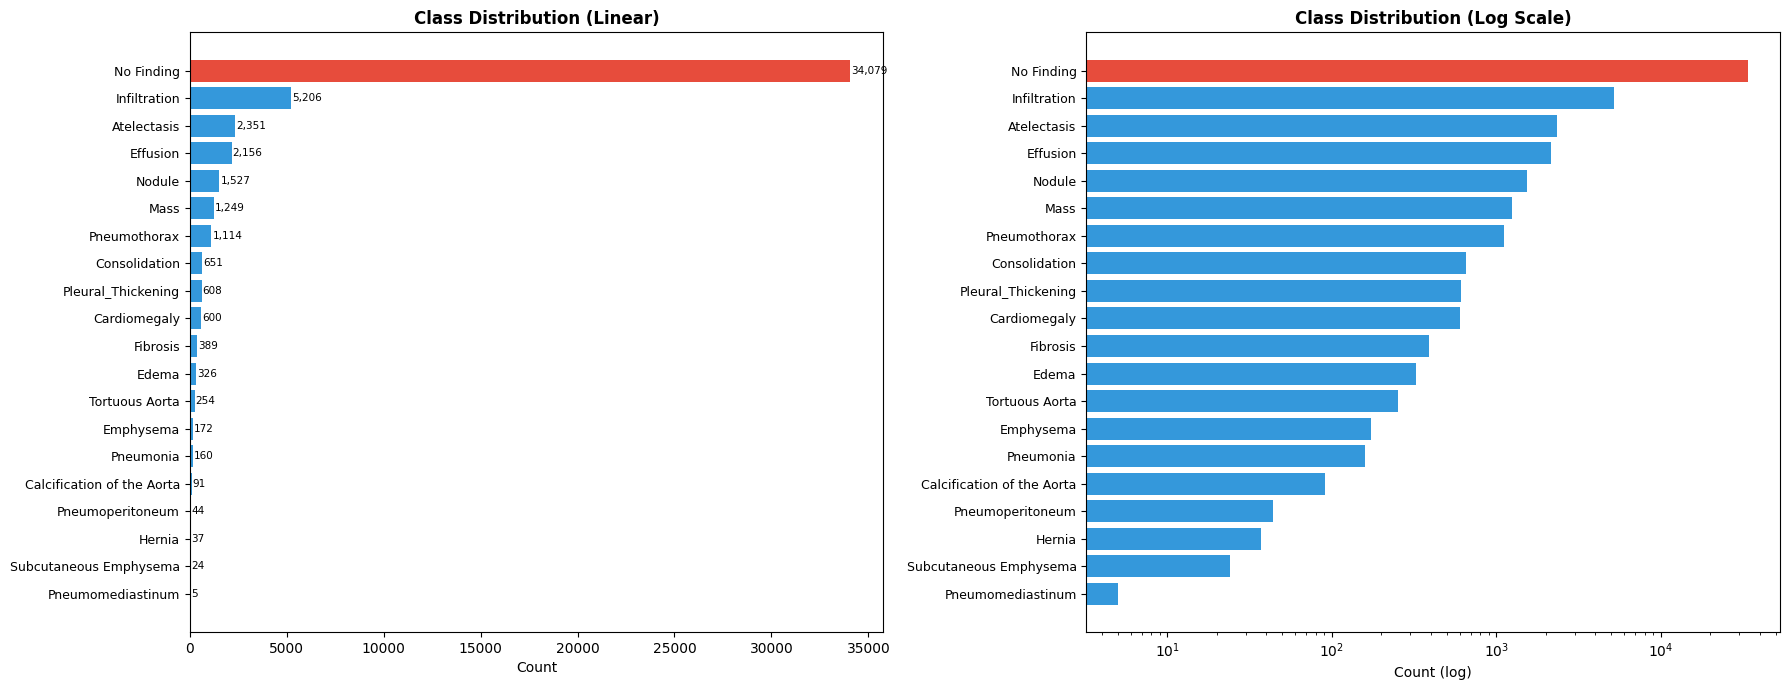

Key: No Finding dominates at 66.8%. Pneumomediastinum has only 5 samples.


In [5]:
# ============================================================
# CELL 5: EDA — CLASS DISTRIBUTION VISUALIZATION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Linear scale
colors = ['#e74c3c' if cls == 'No Finding' else '#3498db' for cls in class_counts.index]
axes[0].barh(range(len(class_counts)), class_counts.values, color=colors)
axes[0].set_yticks(range(len(class_counts)))
axes[0].set_yticklabels(class_counts.index, fontsize=9)
axes[0].set_xlabel('Count')
axes[0].set_title('Class Distribution (Linear)', fontsize=12, fontweight='bold')
for i, (cls, cnt) in enumerate(class_counts.items()):
    axes[0].text(cnt + 50, i, f'{cnt:,}', va='center', fontsize=7.5)
axes[0].invert_yaxis()

# Log scale — reveals extreme imbalance
axes[1].barh(range(len(class_counts)), class_counts.values, color=colors)
axes[1].set_yticks(range(len(class_counts)))
axes[1].set_yticklabels(class_counts.index, fontsize=9)
axes[1].set_xlabel('Count (log)')
axes[1].set_xscale('log')
axes[1].set_title('Class Distribution (Log Scale)', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'class_distribution.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Key: No Finding dominates at 66.8%. Pneumomediastinum has only 5 samples.')


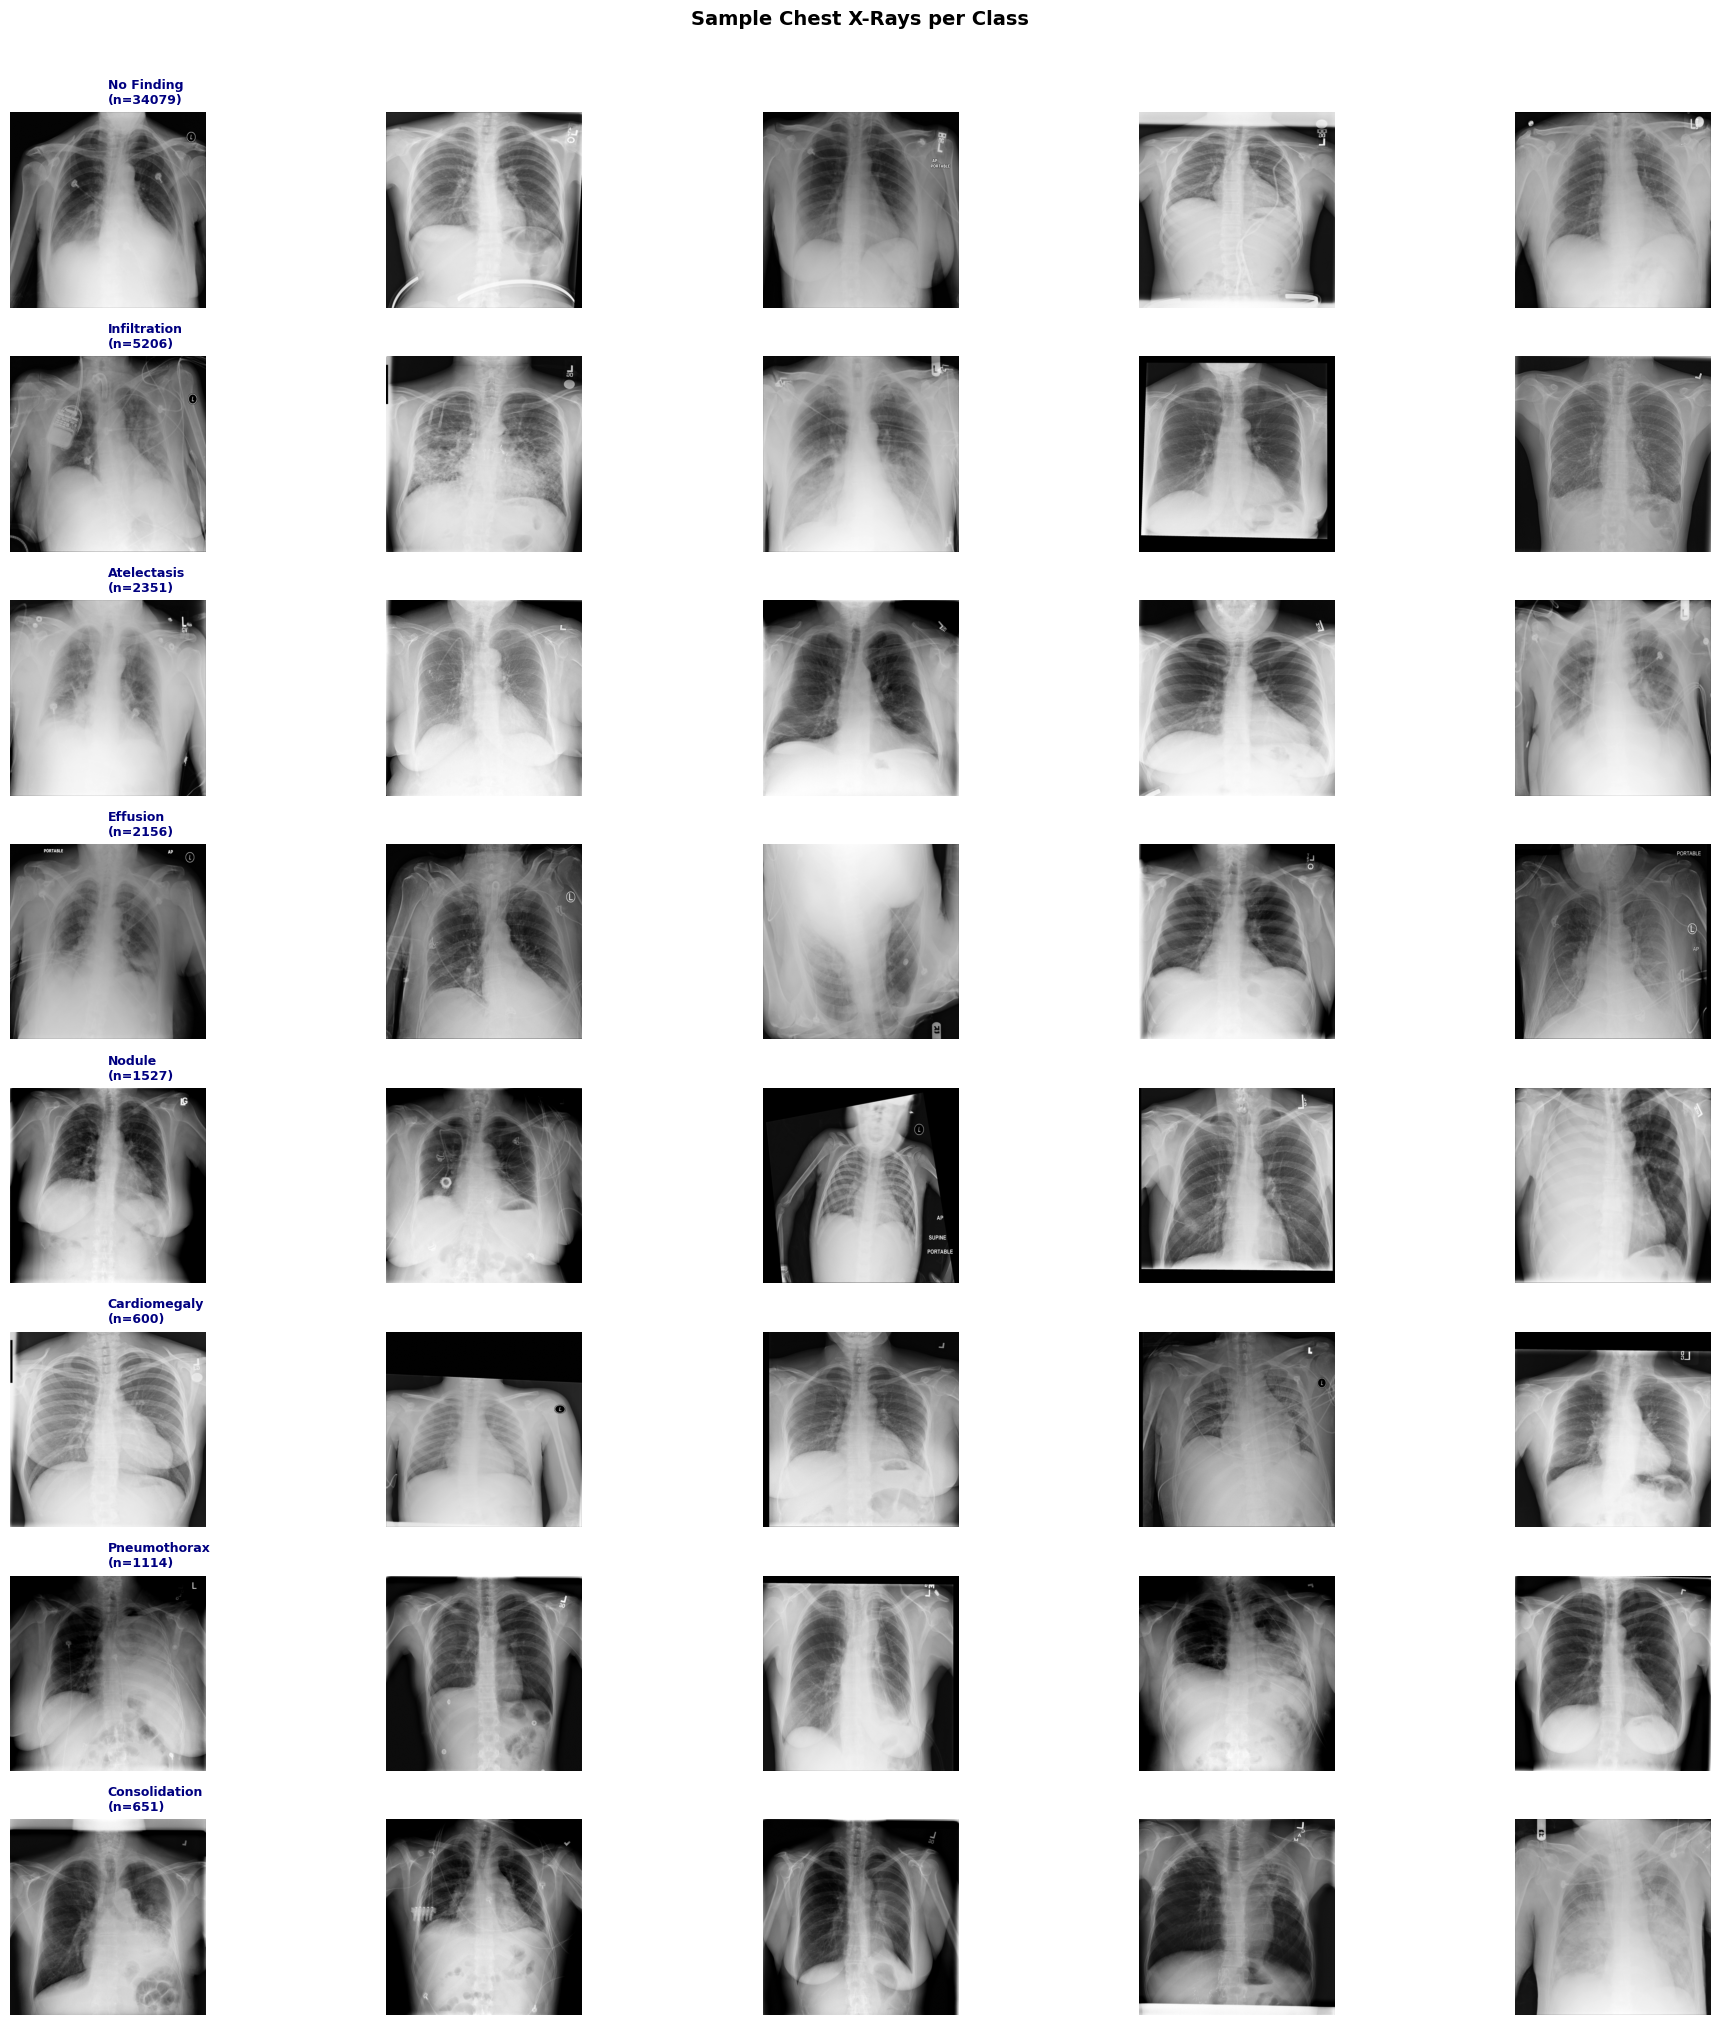

In [6]:
# ============================================================
# CELL 6: EDA — SAMPLE IMAGES PER CLASS
# ============================================================
fig = plt.figure(figsize=(20, 20))
viz_classes = ['No Finding', 'Infiltration', 'Atelectasis', 'Effusion',
               'Nodule', 'Cardiomegaly', 'Pneumothorax', 'Consolidation']
n_cols = 5

for row_idx, cls in enumerate(viz_classes):
    subset = train_df[train_df[cls] == 1]['id'].tolist()
    samples = random.sample(subset, min(n_cols, len(subset)))
    for col_idx, fn in enumerate(samples):
        ax = fig.add_subplot(len(viz_classes), n_cols, row_idx * n_cols + col_idx + 1)
        img_path = os.path.join(IMAGE_DIR, fn)
        if os.path.exists(img_path):
            img = PILImage.open(img_path).convert('L')
            ax.imshow(img, cmap='gray')
        ax.axis('off')
        if col_idx == 0:
            ax.set_title(f'{cls}\n(n={len(subset)})', fontsize=9,
                        fontweight='bold', color='navy', ha='left')

plt.suptitle('Sample Chest X-Rays per Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_images.png'), dpi=100, bbox_inches='tight')
plt.show()


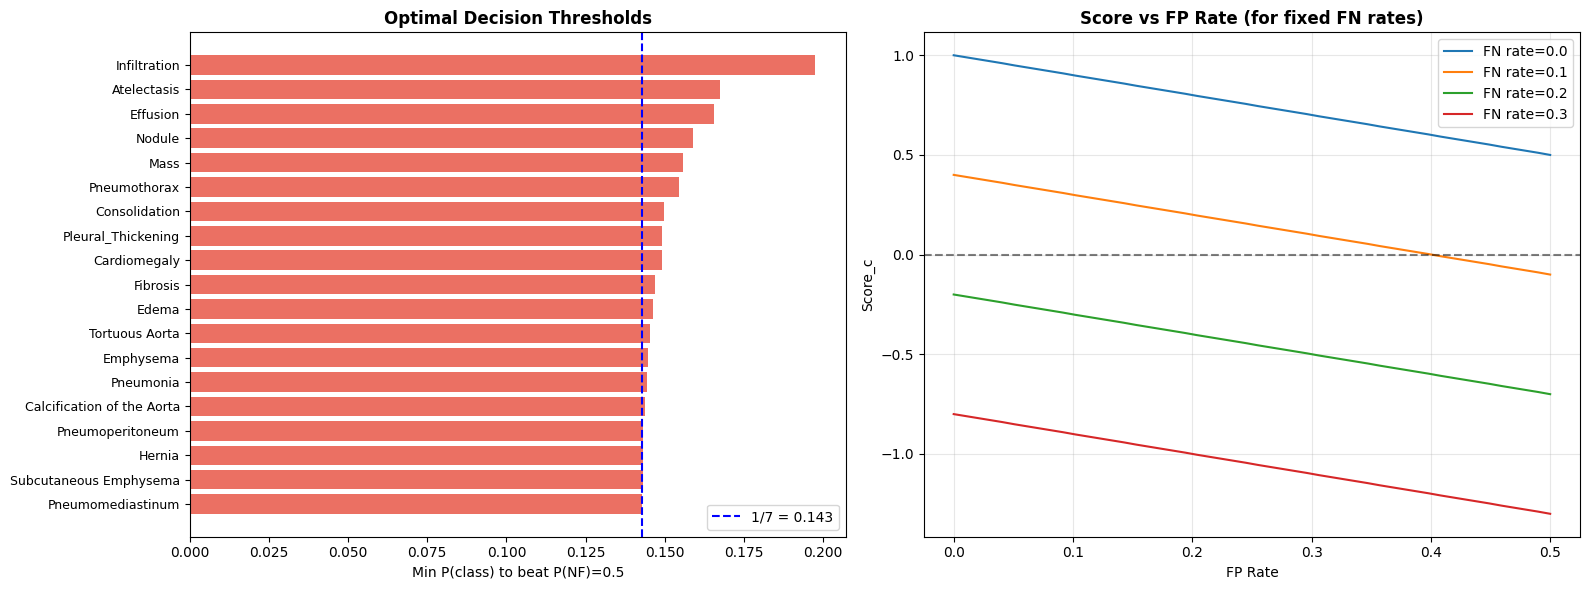

Key: FN rate dominates score. Even 10% FN rate makes score negative.
Rare class needs only P > 0.143 (14.3%) to beat NF at 50%.


In [7]:
# ============================================================
# CELL 7: EDA — SCORING ANALYSIS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Min probability needed to beat P(No Finding) = 0.5
N_NF = class_counts['No Finding']
nf_50_score = (7 * 0.5 - 1) / N_NF

min_probs = {}
for cls in CLASSES:
    if cls == 'No Finding':
        continue
    N_c = class_counts[cls]
    min_p = (nf_50_score * N_c + 1) / 7
    min_probs[cls] = min_p

mp_series = pd.Series(min_probs).sort_values(ascending=False)
axes[0].barh(range(len(mp_series)), mp_series.values, color='#e74c3c', alpha=0.8)
axes[0].set_yticks(range(len(mp_series)))
axes[0].set_yticklabels(mp_series.index, fontsize=9)
axes[0].set_xlabel('Min P(class) to beat P(NF)=0.5')
axes[0].set_title('Optimal Decision Thresholds', fontweight='bold')
axes[0].axvline(x=1/7, color='blue', ls='--', label=f'1/7 = {1/7:.3f}')
axes[0].legend()
axes[0].invert_yaxis()

# Panel 2: FN vs FP cost sensitivity
ax2 = axes[1]
fp_rates = np.linspace(0, 0.5, 50)
for fn_frac in [0.0, 0.1, 0.2, 0.3]:
    scores = [(1000 * (1 - fn_frac) - int(1000 * fp_r) - 5 * 1000 * fn_frac) / 1000
              for fp_r in fp_rates]
    ax2.plot(fp_rates, scores, label=f'FN rate={fn_frac}')
ax2.axhline(y=0, color='black', ls='--', alpha=0.5)
ax2.set_xlabel('FP Rate')
ax2.set_ylabel('Score_c')
ax2.set_title('Score vs FP Rate (for fixed FN rates)', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'scoring_analysis.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Key: FN rate dominates score. Even 10% FN rate makes score negative.')
print(f'Rare class needs only P > {1/7:.3f} ({1/7*100:.1f}%) to beat NF at 50%.')


In [8]:
# ============================================================
# CELL 8: EDA — IMAGE PROPERTIES
# ============================================================
sample_ids = train_df['id'].sample(200, random_state=42).tolist()
means, stds = [], []
for fn in sample_ids:
    fpath = os.path.join(IMAGE_DIR, fn)
    if os.path.exists(fpath):
        arr = np.array(PILImage.open(fpath).convert('RGB')).astype(np.float32) / 255.0
        means.append(arr[..., 0].mean())
        stds.append(arr[..., 0].std())

print(f'Image stats (n={len(means)} samples):')
print(f'  Mean intensity: {np.mean(means):.4f}')
print(f'  Mean std:       {np.mean(stds):.4f}')
print(f'  All 384x384 RGB (grayscale stored as RGB)')
print(f'  Using ImageNet normalization for pretrained backbone')


Image stats (n=200 samples):
  Mean intensity: 0.5015
  Mean std:       0.2287
  All 384x384 RGB (grayscale stored as RGB)
  Using ImageNet normalization for pretrained backbone


In [9]:
# ============================================================
# CELL 9: SCORING FUNCTIONS + OPTIMAL DECISION RULE
# ============================================================
def competition_score(y_true, y_pred, classes=CLASSES, verbose=False):
    """Compute macro-averaged asymmetric competition score.
    Score_c = (TP_c - FP_c - 5*FN_c) / N_c, averaged over all classes.
    """
    scores = []
    for c_idx, cls in enumerate(classes):
        N_c = (y_true == c_idx).sum()
        if N_c == 0:
            continue
        TP = ((y_true == c_idx) & (y_pred == c_idx)).sum()
        FP = ((y_true != c_idx) & (y_pred == c_idx)).sum()
        FN = ((y_true == c_idx) & (y_pred != c_idx)).sum()
        score_c = (TP - FP - 5 * FN) / N_c
        scores.append(score_c)
        if verbose:
            print(f'{cls:<35} N={N_c:5d} | TP={TP:5d} FP={FP:5d} FN={FN:5d} | Score={score_c:+8.4f}')
    macro = np.mean(scores)
    if verbose:
        print('-' * 80)
        print(f'{"MACRO AVERAGE":<35}                                | Score={macro:+8.4f}')
    return macro


def optimal_predict(probs, class_counts, min_train_samples=30):
    """Bayes-optimal decision rule for this scoring function.

    Derivation: Predicting class c for sample x gets:
      +1/N_c if correct (TP), -1/N_c if wrong class (FP), -5/N_c if missed (FN)
    Expected score contribution = [6*P(c|x) - 1] / N_c
    Optimal: c* = argmax_c [(7*P(c|x) - 1) / N_c]

    min_train_samples clamps N_c for ultra-rare classes to prevent
    the 1/N_c boost from causing runaway false positives.
    """
    effective_counts = np.maximum(class_counts, min_train_samples).astype(float)
    decision_scores = (7 * probs - 1) / effective_counts[np.newaxis, :]
    return np.argmax(decision_scores, axis=1)


def find_best_strategy(val_probs, val_labels, class_counts):
    """Automatically evaluate multiple prediction strategies on validation set."""
    strategies = {}
    nf_idx = CLASSES.index('No Finding')

    # 1. Standard argmax
    strategies['argmax'] = competition_score(val_labels, val_probs.argmax(axis=1))

    # 2. Optimal rule with different min_train thresholds
    for min_t in [10, 20, 30, 50, 100, 200]:
        preds = optimal_predict(val_probs, class_counts, min_train_samples=min_t)
        strategies[f'optimal_min{min_t}'] = competition_score(val_labels, preds)

    # 3. Confidence threshold: predict disease only if confident
    for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
        preds = val_probs.argmax(axis=1).copy()
        preds[val_probs.max(axis=1) < thresh] = nf_idx
        strategies[f'thresh_{thresh}'] = competition_score(val_labels, preds)

    # 4. Always No Finding (safety baseline)
    strategies['always_NF'] = competition_score(
        val_labels, np.full(len(val_labels), nf_idx))

    ranked = sorted(strategies.items(), key=lambda x: x[1], reverse=True)
    print('=== Strategy Comparison (validation set) ===')
    for i, (name, score) in enumerate(ranked):
        marker = ' <<<< BEST' if i == 0 else ''
        print(f'  {name:<25} {score:+8.4f}{marker}')
    print(f'\nSelected: {ranked[0][0]} (score={ranked[0][1]:+.4f})')
    return ranked[0][0], strategies


# Sanity test
y_t = np.array([0, 0, 1, 1, 2])
y_p = np.array([0, 1, 1, 1, 2])
print(f'Sanity check: {competition_score(y_t, y_p, classes=["A","B","C"]):.4f}')
print('Scoring functions defined.')


Sanity check: -0.1667
Scoring functions defined.


In [10]:
# ============================================================
# CELL 10: BASELINE ANALYSIS
# ============================================================
y_train = train_df[CLASSES].values.argmax(axis=1)
nf_idx = class_to_idx['No Finding']

print('=== Baseline Strategy Analysis ===\n')
y_nf = np.full(len(y_train), nf_idx)
print(f'Always No Finding:  {competition_score(y_train, y_nf):+.4f}  (FN=-5 for all diseases)')
print(f'Perfect prediction: {competition_score(y_train, y_train):+.4f}  (upper bound)')
np.random.seed(42)
y_rand = np.random.randint(0, 20, len(y_train))
print(f'Random prediction:  {competition_score(y_train, y_rand):+.4f}')
print(f'\nCutoff to beat:     -4.0000')
print(f'\n→ Always-NF scores -4.7. We need only +0.7 improvement over doing nothing.')
print(f'→ Getting 3-4 common disease classes partially right is sufficient.')


=== Baseline Strategy Analysis ===

Always No Finding:  -4.7249  (FN=-5 for all diseases)
Perfect prediction: +1.0000  (upper bound)
Random prediction:  -47.9664

Cutoff to beat:     -4.0000

→ Always-NF scores -4.7. We need only +0.7 improvement over doing nothing.
→ Getting 3-4 common disease classes partially right is sufficient.


In [11]:
# ============================================================
# CELL 11: CLASS WEIGHT ANALYSIS
# ============================================================
# Compute class weights for reference (we analyze but don't use in loss)
total_samples = len(train_df)
inv_freq_weights = total_samples / (len(CLASSES) * class_counts_arr)

print('Class Weights Analysis:')
print(f'{"Class":<35} {"Count":>8} {"InvFreq":>10} {"Capped@3x":>10} {"Capped@10x":>10}')
print('-' * 80)
cap3  = np.clip(inv_freq_weights, None, 3.0)
cap3  = cap3 / cap3.sum() * 20
cap10 = np.clip(inv_freq_weights, None, 10.0)
cap10 = cap10 / cap10.sum() * 20
for i, cls in enumerate(CLASSES):
    print(f'{cls:<35} {class_counts_arr[i]:>8.0f} {inv_freq_weights[i]:>10.3f} '
          f'{cap3[i]:>10.4f} {cap10[i]:>10.4f}')

print()
print('DECISION: Not using class weights in loss function.')
print('Reason: Previous run with class weights (10x cap) + FocalLoss scored -5.')
print('  → Model over-predicted rare classes (val acc 11% vs 67% NF baseline).')
print('  → Instead, we train a calibrated model and use the optimal decision')
print('    rule at inference: c* = argmax_c [(7*P(c|x) - 1) / N_c]')


Class Weights Analysis:
Class                                  Count    InvFreq  Capped@3x Capped@10x
--------------------------------------------------------------------------------
Atelectasis                             2351      1.086     0.4538     0.1878
Cardiomegaly                             600      4.254     1.2542     0.7359
Consolidation                            651      3.920     1.2542     0.6783
Edema                                    326      7.829     1.2542     1.3544
Effusion                                2156      1.184     0.4949     0.2048
Emphysema                                172     14.838     1.2542     1.7301
Fibrosis                                 389      6.561     1.2542     1.1351
Hernia                                    37     68.977     1.2542     1.7301
Infiltration                            5206      0.490     0.2049     0.0848
Mass                                    1249      2.043     0.8542     0.3535
Nodule                               

In [12]:
# ============================================================
# CELL 12: STRATIFIED TRAIN/VAL SPLIT
# ============================================================
y_labels = train_df[CLASSES].values.argmax(axis=1)
train_df['label'] = y_labels

skf = StratifiedKFold(n_splits=CFG['n_folds'], shuffle=True, random_state=CFG['seed'])
train_df['fold'] = -1
for fold, (_, val_idx) in enumerate(skf.split(train_df, y_labels)):
    train_df.loc[val_idx, 'fold'] = fold

df_trn = train_df[train_df['fold'] != CFG['val_fold']].reset_index(drop=True)
df_val = train_df[train_df['fold'] == CFG['val_fold']].reset_index(drop=True)

print(f'Train: {len(df_trn):,} samples | Val: {len(df_val):,} samples')
print(f'\nStratification check:')
for cls in ['No Finding', 'Infiltration', 'Pneumomediastinum']:
    c_idx = class_to_idx[cls]
    t_pct = (df_trn['label'] == c_idx).mean() * 100
    v_pct = (df_val['label'] == c_idx).mean() * 100
    print(f'  {cls:<25} train={t_pct:.2f}%  val={v_pct:.2f}%')


Train: 40,834 samples | Val: 10,209 samples

Stratification check:
  No Finding                train=66.77%  val=66.76%
  Infiltration              train=10.20%  val=10.20%
  Pneumomediastinum         train=0.01%  val=0.01%


In [13]:
# ============================================================
# CELL 13: DATA TRANSFORMS
# ============================================================
NORM_MEAN = [0.485, 0.456, 0.406]  # ImageNet stats (close to dataset mean ~0.502)
NORM_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((CFG['train_img_size'], CFG['train_img_size'])),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=NORM_MEAN, std=NORM_STD),
    T.RandomErasing(p=0.15, scale=(0.02, 0.08)),  # MUST be after ToTensor
])

val_transform = T.Compose([
    T.Resize((CFG['val_img_size'], CFG['val_img_size'])),
    T.ToTensor(),
    T.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

# TTA: deterministic augmentations for test-time averaging
tta_transforms = [
    val_transform,  # Original
    T.Compose([T.Resize((CFG['val_img_size'], CFG['val_img_size'])),
               T.RandomHorizontalFlip(p=1.0),  # Always flip
               T.ToTensor(), T.Normalize(NORM_MEAN, NORM_STD)]),
    T.Compose([T.Resize((int(CFG['val_img_size']*1.1), int(CFG['val_img_size']*1.1))),
               T.CenterCrop(CFG['val_img_size']),  # Zoom in
               T.ToTensor(), T.Normalize(NORM_MEAN, NORM_STD)]),
    T.Compose([T.Resize((CFG['val_img_size'], CFG['val_img_size'])),
               T.RandomRotation(degrees=(10, 10)),  # Fixed 10-degree rotation
               T.ToTensor(), T.Normalize(NORM_MEAN, NORM_STD)]),
]
print(f'Train: {CFG["train_img_size"]}px + augmentation')
print(f'Val:   {CFG["val_img_size"]}px')
print(f'TTA:   {len(tta_transforms)} transforms')


Train: 320px + augmentation
Val:   384px
TTA:   4 transforms


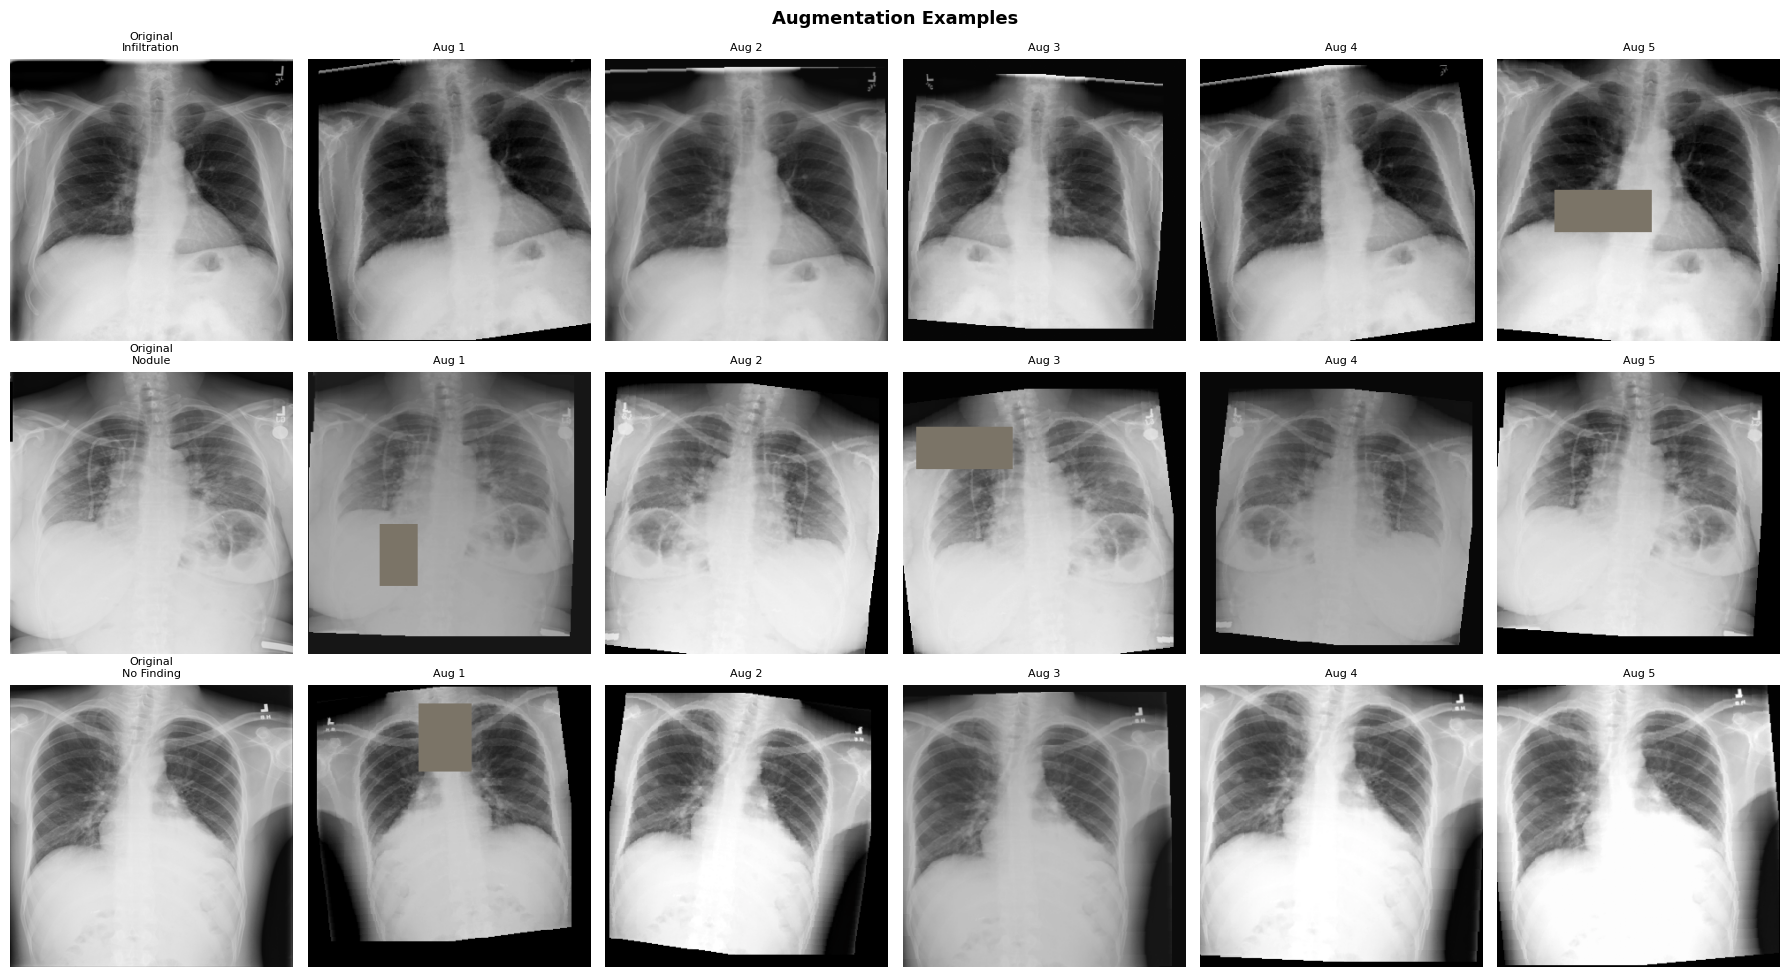

In [14]:
# ============================================================
# CELL 14: AUGMENTATION VISUALIZATION
# ============================================================
fig, axes = plt.subplots(3, 6, figsize=(18, 10))
sample_indices = random.sample(range(len(df_trn)), 3)

for row, idx in enumerate(sample_indices):
    row_data = df_trn.iloc[idx]
    orig_img = PILImage.open(os.path.join(IMAGE_DIR, row_data['id'])).convert('RGB')
    cls_name = CLASSES[int(row_data['label'])]

    axes[row, 0].imshow(orig_img, cmap='gray')
    axes[row, 0].set_title(f'Original\n{cls_name}', fontsize=8)
    axes[row, 0].axis('off')

    mean_t = torch.tensor(NORM_MEAN).view(3, 1, 1)
    std_t  = torch.tensor(NORM_STD).view(3, 1, 1)
    for aug_idx in range(5):
        aug = train_transform(orig_img)
        aug_vis = (aug * std_t + mean_t).clamp(0, 1)
        axes[row, aug_idx+1].imshow(aug_vis.permute(1, 2, 0))
        axes[row, aug_idx+1].set_title(f'Aug {aug_idx+1}', fontsize=8)
        axes[row, aug_idx+1].axis('off')

plt.suptitle('Augmentation Examples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'augmentation_examples.png'), dpi=100)
plt.show()


In [15]:
# ============================================================
# CELL 15: DATASET & DATALOADERS
# ============================================================
class ChestXRayDataset(Dataset):
    def __init__(self, df, image_dir, transform=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = PILImage.open(os.path.join(self.image_dir, row['id'])).convert('RGB')
        if self.transform:
            img = self.transform(img)
        if self.is_test:
            return img, row['id']
        return img, int(row['label'])


# Natural sampling — NO WeightedRandomSampler
# WeightedRandomSampler was removed because it trained the model to expect
# uniform class distribution, causing val accuracy to collapse to 11%.
train_ds = ChestXRayDataset(df_trn, IMAGE_DIR, train_transform)
val_ds   = ChestXRayDataset(df_val, IMAGE_DIR, val_transform)

_pin = (DEVICE.type == 'cuda')
train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=CFG['num_workers'], pin_memory=_pin, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=CFG['val_batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=_pin)

print(f'Train: {len(train_loader)} batches x {CFG["batch_size"]}')
print(f'Val:   {len(val_loader)} batches x {CFG["val_batch_size"]}')

# Verify a sample
img_t, lbl = train_ds[0]
print(f'\nSample: shape={img_t.shape}, label={lbl} ({CLASSES[lbl]})')


Train: 1276 batches x 32
Val:   160 batches x 64

Sample: shape=torch.Size([3, 320, 320]), label=19 (No Finding)


In [16]:
# ============================================================
# CELL 16: MODEL DEFINITION
# ============================================================
class ChestXRayModel(nn.Module):
    """EfficientNet-B4 backbone + custom classification head.

    Architecture:
      backbone (pretrained) → global_avg_pool → BN → Dropout → FC(512) → SiLU
      → BN → Dropout → FC(20)
    """
    def __init__(self, backbone_name, num_classes, pretrained=True, dropout=0.3):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name, pretrained=pretrained,
            num_classes=0, global_pool='avg',
        )
        in_features = self.backbone.num_features

        self.head = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(dropout),
            nn.Linear(in_features, 512),
            nn.SiLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout / 2),
            nn.Linear(512, num_classes),
        )
        # Initialize final layer
        nn.init.xavier_uniform_(self.head[-1].weight)
        nn.init.zeros_(self.head[-1].bias)

    def forward(self, x):
        return self.head(self.backbone(x))


model = ChestXRayModel(CFG['backbone'], CFG['num_classes'],
                        CFG['pretrained'], CFG['dropout']).to(DEVICE)

total_p = sum(p.numel() for p in model.parameters())
train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: {CFG["backbone"]}')
print(f'Params: {total_p:,} total, {train_p:,} trainable')

with torch.no_grad():
    out = model(torch.randn(2, 3, CFG['train_img_size'], CFG['train_img_size']).to(DEVICE))
print(f'Output: {out.shape} → (batch, {CFG["num_classes"]} classes)')


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Model: tf_efficientnet_b4_ns
Params: 18,481,500 total, 18,481,500 trainable
Output: torch.Size([2, 20]) → (batch, 20 classes)


In [17]:
# ============================================================
# CELL 17: LOSS FUNCTION + OPTIMIZER + SCHEDULER
# ============================================================
# LOSS: Plain CrossEntropyLoss with label smoothing
# - NO class weights (destroyed calibration in previous run)
# - NO FocalLoss (too aggressive with class weights)
# - Calibrated probabilities + optimal decision rule is the correct approach
criterion = nn.CrossEntropyLoss(label_smoothing=CFG['label_smoothing'])

# OPTIMIZER: AdamW with differential learning rates
# Backbone (pretrained) gets 10x lower LR than head (random init)
optimizer = torch.optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': CFG['backbone_lr']},
    {'params': model.head.parameters(),     'lr': CFG['lr']},
], weight_decay=CFG['weight_decay'])

# SCHEDULER: OneCycleLR — warmup then cosine decay
scheduler = OneCycleLR(
    optimizer,
    max_lr=[CFG['backbone_lr'], CFG['lr']],
    epochs=CFG['epochs'],
    steps_per_epoch=len(train_loader),
    pct_start=0.1,          # 10% warmup
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4,
)

# AMP (mixed precision)
_amp_device = DEVICE.type if DEVICE.type in ('cuda', 'cpu') else 'cpu'
scaler = GradScaler(_amp_device, enabled=(DEVICE.type == 'cuda'))

print(f'Loss:      CrossEntropyLoss(label_smoothing={CFG["label_smoothing"]})')
print(f'Optimizer: AdamW [backbone_lr={CFG["backbone_lr"]}, head_lr={CFG["lr"]}]')
print(f'Scheduler: OneCycleLR (10% warmup, cosine decay)')
print(f'AMP:       {DEVICE.type == "cuda"}')


Loss:      CrossEntropyLoss(label_smoothing=0.1)
Optimizer: AdamW [backbone_lr=3e-05, head_lr=0.0003]
Scheduler: OneCycleLR (10% warmup, cosine decay)
AMP:       True


In [18]:
# ============================================================
# CELL 18: TRAINING & VALIDATION FUNCTIONS
# ============================================================
def train_one_epoch(model, loader, optimizer, scheduler, scaler, criterion, epoch, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    _amp = device.type if device.type in ('cuda', 'cpu') else 'cpu'

    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        with autocast(_amp, enabled=(device.type == 'cuda')):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CFG['grad_clip'])
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)

        if batch_idx % 200 == 0:
            lr = scheduler.get_last_lr()[-1]
            print(f'  [{batch_idx:4d}/{len(loader)}] Loss:{total_loss/total:.4f} '
                  f'Acc:{100*correct/total:.1f}% LR:{lr:.2e}')

    return total_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_probs, all_labels = [], []
    _amp = device.type if device.type in ('cuda', 'cpu') else 'cpu'

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with autocast(_amp, enabled=(device.type == 'cuda')):
                logits = model(images)
                loss = criterion(logits, labels)
            total_loss += loss.item() * images.size(0)
            all_probs.append(F.softmax(logits, dim=1).cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    return (total_loss / len(loader.dataset),
            np.concatenate(all_probs),
            np.concatenate(all_labels))

print('Training functions defined.')


Training functions defined.


In [19]:
# ============================================================
# CELL 19: MAIN TRAINING LOOP (25 epochs ≈ 4.2 hours on T4)
# ============================================================
best_score = -float('inf')
best_model_path = os.path.join(OUTPUT_DIR, 'best_model.pth')
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_score': [], 'lr': []}
start_time = time.time()

print(f'Training for {CFG["epochs"]} epochs...')
print('=' * 70)

for epoch in range(1, CFG['epochs'] + 1):
    epoch_start = time.time()
    print(f'\nEpoch {epoch}/{CFG["epochs"]}')
    print('-' * 40)

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, scheduler, scaler, criterion, epoch, DEVICE)

    val_loss, val_probs, val_labels = validate(model, val_loader, criterion, DEVICE)

    # Score using argmax (stable metric for model selection)
    val_preds = val_probs.argmax(axis=1)
    val_acc = (val_preds == val_labels).mean()
    val_score = competition_score(val_labels, val_preds)

    elapsed = time.time() - epoch_start
    total_elapsed = (time.time() - start_time) / 60

    print(f'  Train — Loss:{train_loss:.4f}  Acc:{train_acc*100:.1f}%')
    print(f'  Val   — Loss:{val_loss:.4f}  Acc:{val_acc*100:.1f}%  Score:{val_score:+.4f}')
    print(f'  Time: {elapsed:.0f}s (total: {total_elapsed:.1f} min)')

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_score'].append(val_score)
    history['lr'].append(scheduler.get_last_lr()[-1])

    # Save checkpoint on best score
    if val_score > best_score:
        best_score = val_score
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'score': best_score,
        }, best_model_path)
        print(f'  >>> New best! Score={best_score:+.4f} — saved.')

total_time = (time.time() - start_time) / 60
print(f'\nTraining complete in {total_time:.1f} min. Best score: {best_score:+.4f}')


Training for 25 epochs...

Epoch 1/25
----------------------------------------
  [   0/1276] Loss:4.1220 Acc:3.1% LR:1.20e-05
  [ 200/1276] Loss:3.8451 Acc:4.8% LR:1.48e-05
  [ 400/1276] Loss:3.7299 Acc:5.9% LR:2.31e-05
  [ 600/1276] Loss:3.6263 Acc:8.4% LR:3.65e-05
  [ 800/1276] Loss:3.5244 Acc:10.7% LR:5.46e-05
  [1000/1276] Loss:3.4122 Acc:13.6% LR:7.65e-05
  [1200/1276] Loss:3.2829 Acc:17.2% LR:1.02e-04
  Train — Loss:3.2286  Acc:18.8%
  Val   — Loss:2.0072  Acc:58.6%  Score:-4.9461
  Time: 693s (total: 11.5 min)
  >>> New best! Score=-4.9461 — saved.

Epoch 2/25
----------------------------------------
  [   0/1276] Loss:2.5060 Acc:40.6% LR:1.12e-04
  [ 200/1276] Loss:2.0905 Acc:56.6% LR:1.39e-04
  [ 400/1276] Loss:1.9685 Acc:60.4% LR:1.68e-04
  [ 600/1276] Loss:1.9080 Acc:61.9% LR:1.96e-04
  [ 800/1276] Loss:1.8653 Acc:62.9% LR:2.22e-04
  [1000/1276] Loss:1.8358 Acc:63.5% LR:2.46e-04
  [1200/1276] Loss:1.8190 Acc:63.8% LR:2.66e-04
  Train — Loss:1.8139  Acc:63.9%
  Val   — Loss:1

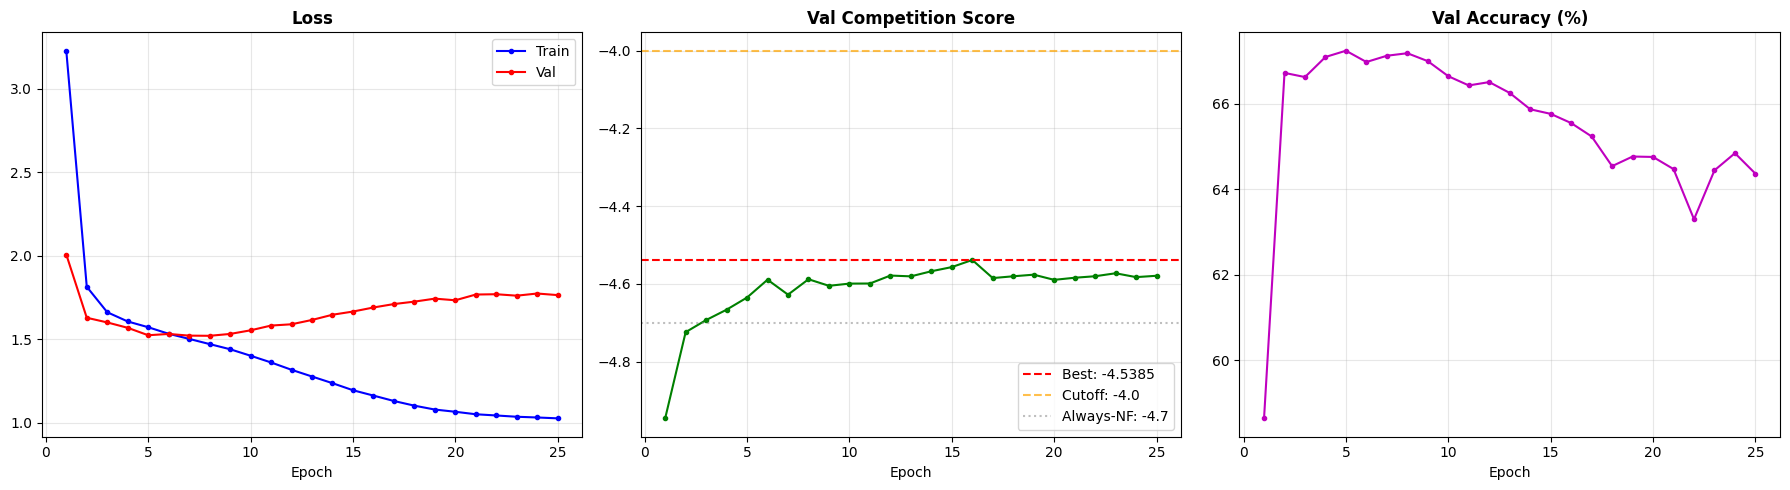

In [20]:
# ============================================================
# CELL 20: TRAINING CURVES
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ep = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], 'b-o', label='Train', ms=3)
axes[0].plot(ep, history['val_loss'],   'r-o', label='Val', ms=3)
axes[0].set_title('Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['val_score'], 'g-o', ms=3)
axes[1].axhline(y=best_score, color='red', ls='--', label=f'Best: {best_score:+.4f}')
axes[1].axhline(y=-4.0, color='orange', ls='--', alpha=0.7, label='Cutoff: -4.0')
axes[1].axhline(y=-4.7, color='gray', ls=':', alpha=0.5, label='Always-NF: -4.7')
axes[1].set_title('Val Competition Score', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, [a*100 for a in history['val_acc']], 'm-o', ms=3)
axes[2].set_title('Val Accuracy (%)', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=120)
plt.show()


In [21]:
# ============================================================
# CELL 21: LOAD BEST MODEL + DETAILED VALIDATION ANALYSIS
# ============================================================
checkpoint = torch.load(best_model_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Loaded best model from epoch {checkpoint["epoch"]} (score={checkpoint["score"]:+.4f})')

# Full validation pass
_, val_probs, val_labels = validate(model, val_loader, criterion, DEVICE)

# Per-class score breakdown
print('\n=== Per-Class Scores (argmax) ===')
_ = competition_score(val_labels, val_probs.argmax(axis=1), verbose=True)

# Find best strategy automatically
print()
best_strategy, all_strategies = find_best_strategy(val_probs, val_labels, class_counts_arr)


Loaded best model from epoch 16 (score=-4.5385)

=== Per-Class Scores (argmax) ===
Atelectasis                         N=  470 | TP=   47 FP=   83 FN=  423 | Score= -4.5766
Cardiomegaly                        N=  120 | TP=    5 FP=    4 FN=  115 | Score= -4.7833
Consolidation                       N=  131 | TP=   11 FP=   53 FN=  120 | Score= -4.9008
Edema                               N=   65 | TP=    3 FP=   10 FN=   62 | Score= -4.8769
Effusion                            N=  431 | TP=  118 FP=  169 FN=  313 | Score= -3.7494
Emphysema                           N=   35 | TP=    0 FP=    0 FN=   35 | Score= -5.0000
Fibrosis                            N=   78 | TP=    0 FP=    1 FN=   78 | Score= -5.0128
Hernia                              N=    7 | TP=    0 FP=    0 FN=    7 | Score= -5.0000
Infiltration                        N= 1041 | TP=   90 FP=  271 FN=  951 | Score= -4.7416
Mass                                N=  250 | TP=   41 FP=   93 FN=  209 | Score= -4.3880
Nodule           

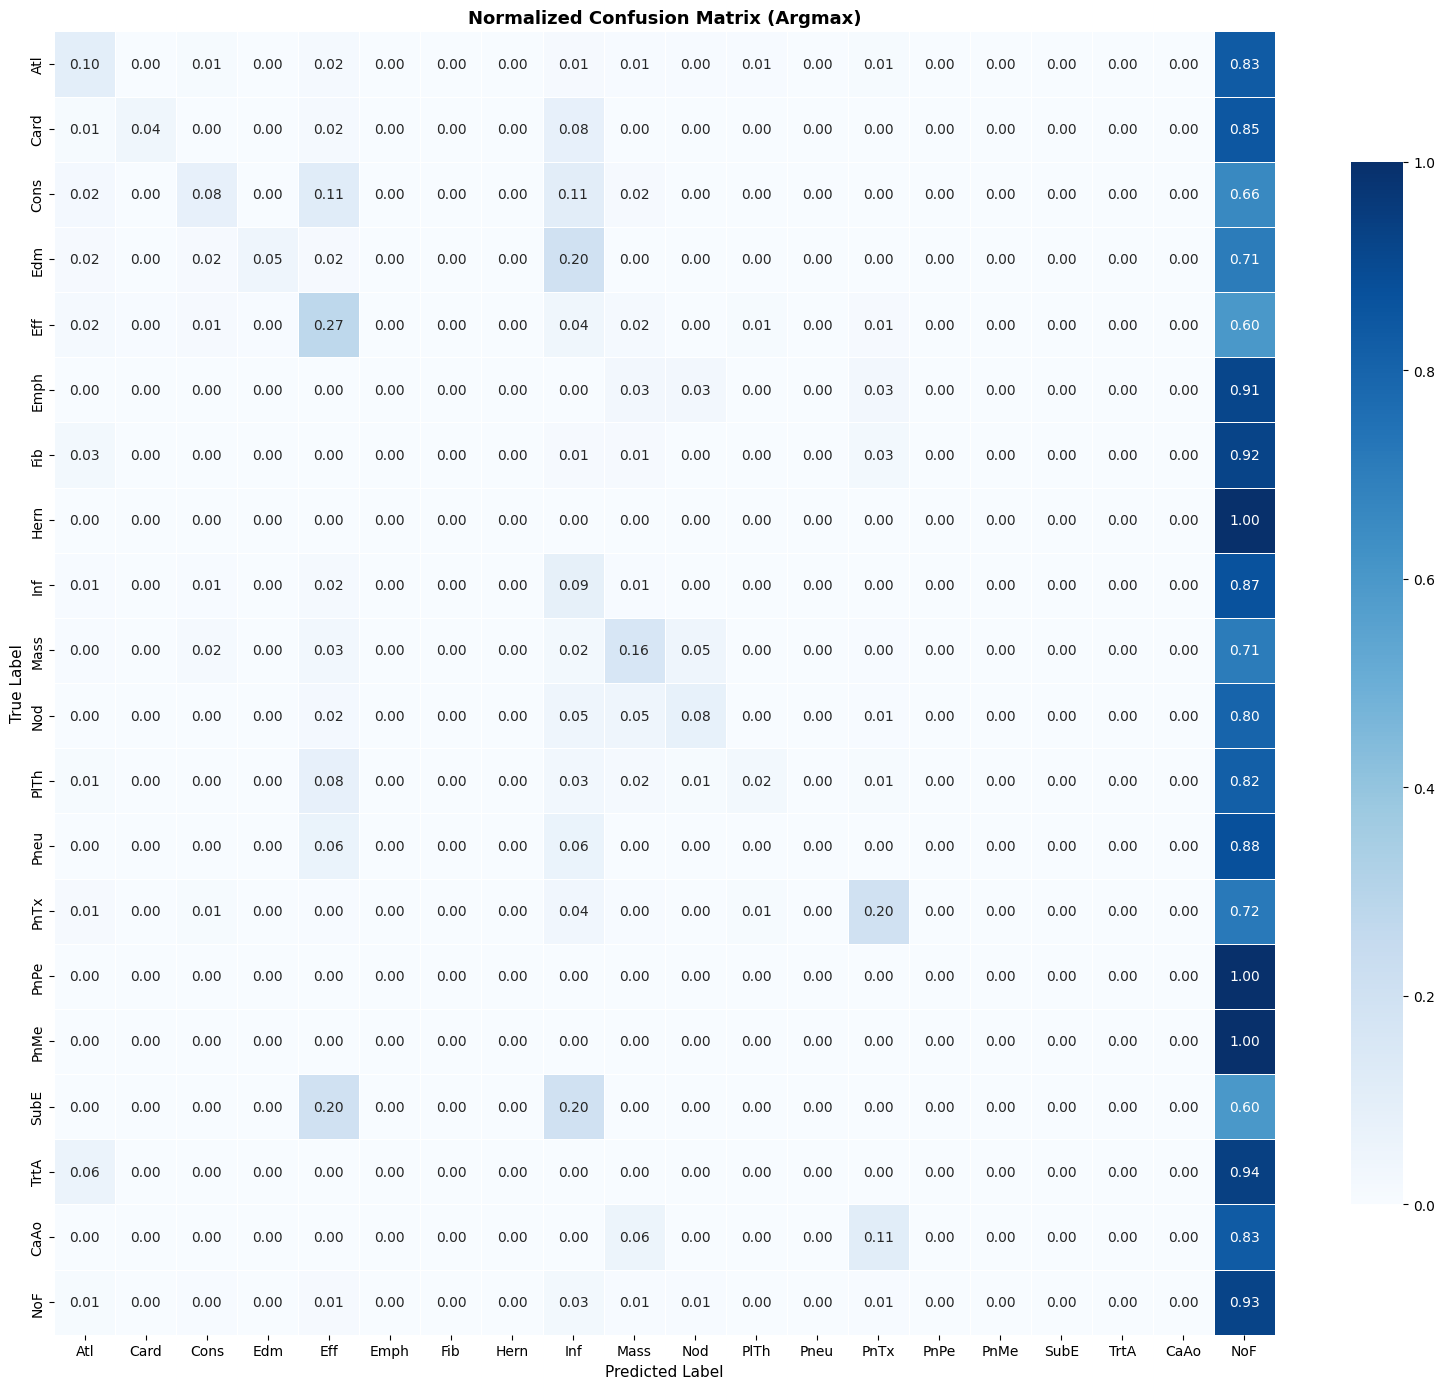

In [22]:
# ============================================================
# CELL 22: CONFUSION MATRIX
# ============================================================
best_preds = val_probs.argmax(axis=1)
cm = confusion_matrix(val_labels, best_preds, labels=range(len(CLASSES)))
cm_norm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], 1)

fig, ax = plt.subplots(figsize=(16, 14))
short = ['Atl','Card','Cons','Edm','Eff','Emph','Fib','Hern',
         'Inf','Mass','Nod','PlTh','Pneu','PnTx','PnPe',
         'PnMe','SubE','TrtA','CaAo','NoF']
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=short, yticklabels=short, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_title('Normalized Confusion Matrix (Argmax)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=120)
plt.show()


In [23]:
# ============================================================
# CELL 23: INFERENCE WITH TEST-TIME AUGMENTATION (TTA)
# ============================================================
def predict_tta(model, image_ids, image_dir, transforms, batch_size, device, num_workers=4):
    """Run inference with TTA — averages softmax probabilities across augmentations."""
    model.eval()
    all_avg = None
    _amp = device.type if device.type in ('cuda', 'cpu') else 'cpu'

    for t_idx, tfm in enumerate(transforms):
        print(f'  TTA {t_idx+1}/{len(transforms)}...')
        ds = ChestXRayDataset(
            pd.DataFrame({'id': image_ids, 'label': 0}),
            image_dir, tfm, is_test=False
        )
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                           num_workers=num_workers, pin_memory=(device.type=='cuda'))

        probs_list = []
        with torch.no_grad():
            for images, _ in loader:
                images = images.to(device, non_blocking=True)
                with autocast(_amp, enabled=(device.type=='cuda')):
                    logits = model(images)
                probs_list.append(F.softmax(logits, dim=1).cpu().numpy())

        probs_arr = np.concatenate(probs_list)
        all_avg = probs_arr if all_avg is None else all_avg + probs_arr

    return all_avg / len(transforms)


print('Running TTA inference on test set...')
tta_start = time.time()
test_ids = test_df['id'].tolist()

test_probs = predict_tta(
    model, test_ids, IMAGE_DIR,
    tta_transforms[:CFG['tta_n']],
    CFG['val_batch_size'], DEVICE, CFG['num_workers']
)

tta_time = (time.time() - tta_start) / 60
print(f'\nTTA done in {tta_time:.1f} min')
print(f'Shape: {test_probs.shape}')
print(f'Sum check: {test_probs.sum(axis=1).mean():.4f} (should be ~1.0)')


Running TTA inference on test set...
  TTA 1/4...
  TTA 2/4...
  TTA 3/4...
  TTA 4/4...

TTA done in 6.8 min
Shape: (17015, 20)
Sum check: 1.0000 (should be ~1.0)


In [24]:
# ============================================================
# CELL 24: BUILD SUBMISSION — best strategy from validation
# ============================================================

def apply_strategy(strategy_name, probs, class_counts, classes):
    """Apply a named strategy to probability matrix."""
    nf_idx = classes.index('No Finding')
    if strategy_name == 'argmax':
        return probs.argmax(axis=1)
    elif strategy_name.startswith('optimal_min'):
        min_t = int(strategy_name.split('min')[1])
        return optimal_predict(probs, class_counts, min_train_samples=min_t)
    elif strategy_name.startswith('thresh_'):
        thresh = float(strategy_name.split('_')[1])
        preds = probs.argmax(axis=1).copy()
        preds[probs.max(axis=1) < thresh] = nf_idx
        return preds
    elif strategy_name == 'always_NF':
        return np.full(len(probs), nf_idx)
    else:
        raise ValueError(f'Unknown strategy: {strategy_name}')


def build_submission(test_ids, preds, classes, output_path):
    """Build and save a properly formatted submission CSV."""
    sub = pd.DataFrame({'id': test_ids})
    for cls in classes:
        sub[cls] = 0
    for i, pred_idx in enumerate(preds):
        sub.iloc[i, 1 + pred_idx] = 1  # +1 because col 0 is 'id'

    # Safety checks
    assert len(sub) == len(test_ids), f'Row mismatch: {len(sub)} vs {len(test_ids)}'
    assert (sub[classes].sum(axis=1) == 1).all(), 'Not all rows single-label!'

    sub.to_csv(output_path, index=False)
    return sub


# Primary submission: best strategy
print(f'Strategy: {best_strategy}')
test_preds = apply_strategy(best_strategy, test_probs, class_counts_arr, CLASSES)
sub_path = os.path.join(OUTPUT_DIR, 'submission.csv')
submission = build_submission(test_ids, test_preds, CLASSES, sub_path)
print(f'\nPrimary submission saved: {sub_path} ({len(submission)} rows)')

print(f'\nPrediction distribution:')
for cls in CLASSES:
    n = int(submission[cls].sum())
    if n > 0:
        print(f'  {cls:<35} {n:>5} ({n/len(submission)*100:.1f}%)')


Strategy: argmax

Primary submission saved: /kaggle/working/submission.csv (17015 rows)

Prediction distribution:
  Atelectasis                           186 (1.1%)
  Cardiomegaly                           11 (0.1%)
  Consolidation                          57 (0.3%)
  Edema                                  20 (0.1%)
  Effusion                              520 (3.1%)
  Fibrosis                                7 (0.0%)
  Infiltration                          393 (2.3%)
  Mass                                  178 (1.0%)
  Nodule                                138 (0.8%)
  Pleural_Thickening                     33 (0.2%)
  Pneumothorax                          165 (1.0%)
  Tortuous Aorta                          1 (0.0%)
  No Finding                          15306 (90.0%)


In [25]:
# ============================================================
# CELL 25: BACKUP SUBMISSIONS
# ============================================================
# Save multiple submissions in case the best strategy underperforms on test

# Argmax (safest)
preds_argmax = apply_strategy('argmax', test_probs, class_counts_arr, CLASSES)
build_submission(test_ids, preds_argmax, CLASSES,
                 os.path.join(OUTPUT_DIR, 'submission_argmax.csv'))
print(f'Saved: submission_argmax.csv ({len(test_ids)} rows)')

# Optimal rule (min_train=50, conservative)
preds_opt = apply_strategy('optimal_min50', test_probs, class_counts_arr, CLASSES)
build_submission(test_ids, preds_opt, CLASSES,
                 os.path.join(OUTPUT_DIR, 'submission_optimal.csv'))
print(f'Saved: submission_optimal.csv ({len(test_ids)} rows)')

# Threshold 0.5
preds_t50 = apply_strategy('thresh_0.5', test_probs, class_counts_arr, CLASSES)
build_submission(test_ids, preds_t50, CLASSES,
                 os.path.join(OUTPUT_DIR, 'submission_thresh50.csv'))
print(f'Saved: submission_thresh50.csv ({len(test_ids)} rows)')

print(f'\n=== ALL SUBMISSIONS READY ===')
print(f'  1. submission.csv          ← best strategy ({best_strategy}) — SUBMIT THIS')
print(f'  2. submission_argmax.csv   ← safe argmax fallback')
print(f'  3. submission_optimal.csv  ← optimal rule (min_train=50)')
print(f'  4. submission_thresh50.csv ← argmax with 50% confidence threshold')
print(f'\nAll have {len(test_ids)} rows, verified single-label.')


Saved: submission_argmax.csv (17015 rows)
Saved: submission_optimal.csv (17015 rows)
Saved: submission_thresh50.csv (17015 rows)

=== ALL SUBMISSIONS READY ===
  1. submission.csv          ← best strategy (argmax) — SUBMIT THIS
  2. submission_argmax.csv   ← safe argmax fallback
  3. submission_optimal.csv  ← optimal rule (min_train=50)
  4. submission_thresh50.csv ← argmax with 50% confidence threshold

All have 17015 rows, verified single-label.
